# Mass transport: the rotating disk electrode (RDE)

An electrode reaction can be limited not by its kinetics but by how fast reactant reaches the surface. A rotating disk electrode pins a steady diffusion layer of thickness `δ ∝ ω^(−1/2)`, giving a mass-transfer coefficient `k_m = 0.62 D^(2/3) ν^(−1/6) ω^(1/2)` (Levich). `discopt.mkm` models this with a `RotatingDiskElectrode` reactor: a solution species' **surface** activity becomes an unknown set by balancing the diffusion flux against the reaction,

$$ k_m\,(C_\text{bulk} - C_\text{surface}) + r = 0, $$

so the current crosses over from kinetic to transport control, the Koutecký-Levich picture `1/j = 1/j_kinetic + 1/j_Levich`. We use the **outer-sphere** couple `Fe²⁺ → Fe³⁺ + e⁻`, which has no adsorbed intermediate at all: the model is just two solution species and one electron-transfer step.

In [1]:
%matplotlib inline

In [2]:
import numpy as np, matplotlib.pyplot as plt
import discopt.mkm as mk
R, T, F = 8.617e-5, 298.0, 1.0

def fe_rde(omega, A=3e-5, U=0.35, Cb_Fe2=1.0, Cb_Fe3=0.0, D=1e-5):
    """Outer-sphere Fe2+ -> Fe3+ + e- (oxidation, n_electrons = -1) on an RDE."""
    m = mk.Model('fe', T=T, R=R, U=U, F=F)
    Fe2 = m.gas('Fe2+', H=0.0, S=0.0, composition={'Fe': 1})
    Fe3 = m.gas('Fe3+', H=0.2, S=0.0, composition={'Fe': 1})   # G(Fe3+) - G(Fe2+) = 0.2 eV -> U_eq = 0.2 V
    rxn = m.step(Fe2 >> Fe3, A=A, Ea=0.0, n_electrons=-1, beta=0.5)
    rde = mk.RotatingDiskElectrode(bulk={Fe2: Cb_Fe2, Fe3: Cb_Fe3}, omega=omega,
                                   diffusivities={Fe2: D, Fe3: D})
    return m, Fe2, Fe3, rxn, rde

m, Fe2, Fe3, rxn, rde = fe_rde(omega=400.0)
print('no adsorbates (outer-sphere):', m.adsorbates, ' sites:', m.sites)
m

no adsorbates (outer-sphere): []  sites: []


#,reaction,kinetics,type
1,Fe2+ ⇌ Fe3+,"A=3e-05, Ea=0",reversible


## Polarization curves: kinetic onset, then a Levich plateau

Sweep the potential at several rotation rates. The anodic current first rises with overpotential (electron-transfer control) and then **saturates at the Levich limit** set by transport; faster rotation lifts the plateau (`j_lim ∝ ω^(1/2)`).

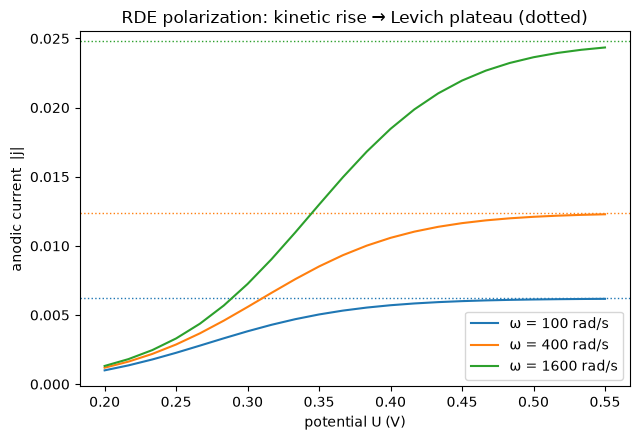

In [3]:
Us = np.linspace(0.20, 0.55, 22)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for w, c in [(100.0, 'C0'), (400.0, 'C1'), (1600.0, 'C2')]:
    j = []
    for U in Us:
        m, Fe2, Fe3, rxn, rde = fe_rde(omega=w, U=U)
        sol = mk.solve_steady_state(m, rde)
        j.append(F * abs(sol.rate_of_progress(rxn)))
    ax.plot(Us, j, c, label=f'ω = {w:.0f} rad/s')
    ax.axhline(rde.limiting_current(Fe2, 1, F), color=c, ls=':', lw=1)
ax.set_xlabel('potential U (V)'); ax.set_ylabel('anodic current  |j|')
ax.set_title('RDE polarization: kinetic rise → Levich plateau (dotted)')
ax.legend(); fig.tight_layout()

## Levich: the limiting current scales as ω$^{1/2}$

The transport-limited (high-overpotential) current is `j_lim = 0.62 n F D^(2/3) ν^(−1/6) C_bulk · ω^(1/2)`, a straight line through the origin in `ω^(1/2)`.

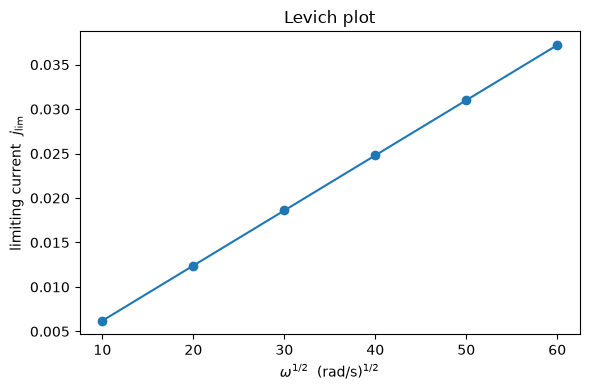

In [4]:
omega = np.array([100., 400., 900., 1600., 2500., 3600.])
jlim = []
for w in omega:
    m, Fe2, Fe3, rxn, rde = fe_rde(omega=w, A=1e4, U=0.8)   # fast kinetics -> fully transport limited
    jlim.append(F * abs(mk.solve_steady_state(m, rde).rate_of_progress(rxn)))
jlim = np.array(jlim)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.sqrt(omega), jlim, 'o-')
ax.set_xlabel(r'$\omega^{1/2}$  (rad/s)$^{1/2}$'); ax.set_ylabel('limiting current  $j_\\mathrm{lim}$')
ax.set_title('Levich plot'); fig.tight_layout()

## Koutecký-Levich: separate kinetics from transport

At a fixed potential in the **mixed-control** region, `1/j` is linear in `ω^(−1/2)`. The slope is the Levich (transport) term and the **intercept is the purely kinetic current** `1/j_kinetic`, the value you would measure with infinitely fast rotation.

kinetic current from the intercept: j_kin = 0.0273
expected F·k_f·C_bulk            : 0.0273


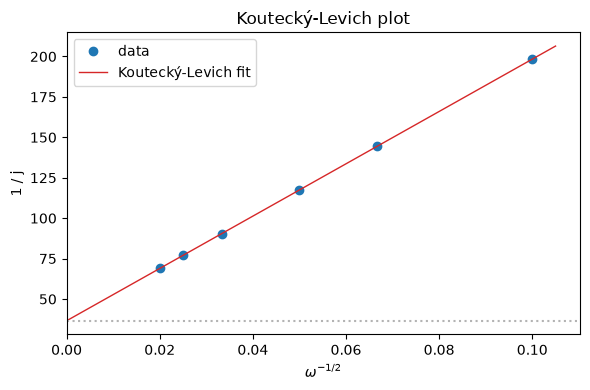

In [5]:
omega = np.array([100., 225., 400., 900., 1600., 2500.])
j = []
for w in omega:
    m, Fe2, Fe3, rxn, rde = fe_rde(omega=w, A=3e-5, U=0.35)
    j.append(F * abs(mk.solve_steady_state(m, rde).rate_of_progress(rxn)))
j = np.array(j)
x = omega ** -0.5
slope, intercept = np.polyfit(x, 1.0 / j, 1)
j_kin = 1.0 / intercept
kf = 3e-5 * np.exp(0.5 * F * 0.35 / (R * T))     # A exp(-beta n F U / RT), n = -1
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, 1.0 / j, 'o', label='data')
xx = np.linspace(0, x.max() * 1.05, 50)
ax.plot(xx, slope * xx + intercept, 'C3-', lw=1, label='Koutecký-Levich fit')
ax.axhline(intercept, color='0.7', ls=':')
ax.set_xlabel(r'$\omega^{-1/2}$'); ax.set_ylabel('1 / j'); ax.set_xlim(left=0)
ax.set_title('Koutecký-Levich plot'); ax.legend(); fig.tight_layout()
print(f'kinetic current from the intercept: j_kin = {j_kin:.4f}')
print(f'expected F·k_f·C_bulk            : {F * kf * 1.0:.4f}')

## Takeaways

- `RotatingDiskElectrode` (and the general `MassTransferReactor`) couple a solution species' surface activity to the bulk through a Levich mass-transfer coefficient, so the steady state captures the **kinetic-to-mass-transport crossover** without any new solver.
- The limiting current follows the **Levich** law `j_lim ∝ ω^(1/2)`, and a **Koutecký-Levich** plot (`1/j` vs `ω^(−1/2)`) separates the transport slope from the kinetic intercept.
- **Outer-sphere** electron transfers (no adsorbed intermediate) are modeled directly: a reaction between solution species only, with `n_electrons` for the charge transfer. Combined with the Butler-Volmer kinetics from the electrochemistry subpackage, this is the full mixed kinetic/transport picture for a soluble redox couple.